<a href="https://colab.research.google.com/github/gabynirmal/pcos-analysis/blob/main/PCOS_cnn_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS 4420 — PCOS Classification: 1D CNN (Keras)
**Dataset:** [Kaggle PCOS Dataset](https://www.kaggle.com/datasets/shreyasvedpathak/pcos-dataset)  
**Model:** 1D Convolutional Neural Network using Keras  
**Task:** Binary classification — PCOS (Y/N)

Since our dataset is tabular (not image-based), we use a **1D CNN**.  
The idea is to reshape each patient's feature vector into a sequence, then let
convolutional filters slide over groups of neighboring features to pick up local patterns.
This is different from an MLP, which treats every feature independently.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 1. Load and Clean the Data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving PCOS_data.csv to PCOS_data.csv


In [3]:
# load the dataset
df = pd.read_csv('PCOS_data.csv')

print('Shape:', df.shape)
df.head()

Shape: (541, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [4]:
# drop columns that are just IDs or almost entirely empty
df = df.drop(columns=['Sl. No', 'Patient File No.', 'Unnamed: 44'], errors='ignore')

# separate the target
y = df['PCOS (Y/N)'].values
# reorder features so clinically important PCOS indicators
# are grouped together at the front of the sequence
# based on Rotterdam criteria and literature (Barrera et al. 2023,
# Zad et al. 2024, Kermanshahchi et al. 2024)
priority_features = [
    'Follicle No. (L)',       # Rotterdam criterion: polycystic morphology
    'Follicle No. (R)',       # Rotterdam criterion: polycystic morphology
    'Avg. F size (L) (mm)',   # follicle size
    'Avg. F size (R) (mm)',   # follicle size
    'LH(mIU/mL)',             # Rotterdam criterion: hyperandrogenism marker
    'FSH(mIU/mL)',            # key hormonal predictor (Zad et al. 2024)
    'FSH/LH',                 # ratio most predictive per literature
    'AMH(ng/mL)',             # strong PCOS biomarker
    'Cycle(R/I)',             # Rotterdam criterion: oligo/anovulation
    'Cycle length(days)',     # cycle irregularity
    'Waist:Hip Ratio',        # metabolic marker
    'Weight gain(Y/N)',       # symptom indicator
    'hair growth(Y/N)',       # hyperandrogenism symptom
    'Skin darkening (Y/N)',   # symptom indicator
    'Pimples(Y/N)',           # hyperandrogenism symptom
]

# put priority features first, then all remaining features after
remaining_features = [c for c in df.columns
                      if c not in priority_features
                      and c != 'PCOS (Y/N)']
ordered_cols = priority_features + remaining_features
X = df[ordered_cols]

# force everything to numeric (some columns have stray characters)
X = X.apply(pd.to_numeric, errors='coerce')

# fill any remaining NaNs with the column median
X = X.fillna(X.median())

print('Features shape:', X.shape)
print('Class balance  — PCOS=1:', y.sum(), '| No PCOS=0:', (y == 0).sum())

Features shape: (541, 41)
Class balance  — PCOS=1: 177 | No PCOS=0: 364


## 2. Train/Test Split and Normalization

In [5]:
# 80/20 split, stratified so both splits have the same class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.20, random_state=42, stratify=y
)

# z-score normalization — fit only on training data to avoid data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (432, 41) | Test: (109, 41)


## 3. Reshape for 1D CNN

Keras expects 1D CNN input to have shape `(samples, steps, channels)`.  
We treat each feature as one time-step with a single channel, so we just
add a trailing dimension: `(n_samples, n_features, 1)`.

In [6]:
# add the channel dimension
X_train_cnn = X_train[..., np.newaxis]   # (432, 43, 1)
X_test_cnn  = X_test[..., np.newaxis]    # (109, 43, 1)

print('CNN input shape (train):', X_train_cnn.shape)
print('CNN input shape (test) :', X_test_cnn.shape)

CNN input shape (train): (432, 41, 1)
CNN input shape (test) : (109, 41, 1)


## 4. Build the 1D CNN

Architecture:
- **Conv1D (32 filters, kernel=3)** — scans groups of 3 neighboring features
- **MaxPooling1D** — keeps only the strongest activations, reduces size
- **Conv1D (64 filters, kernel=3)** — deeper feature extraction
- **GlobalAveragePooling1D** — collapses the sequence into a single vector
- **Dense (64, ReLU)** — fully connected layer
- **Dropout (0.3)** — randomly drops neurons during training to prevent overfitting
- **Dense (1, Sigmoid)** — outputs a probability between 0 and 1

In [7]:
# get the number of features from the training data
n_features = X_train_cnn.shape[1]

# build the model
model = keras.Sequential([
    # first block — wider kernel to capture the grouped clinical features
    layers.Conv1D(filters=32, kernel_size=5, activation='relu',
                  input_shape=(n_features, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    # second block — narrower kernel for finer local patterns
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),

    # fully connected head
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 37, 32)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 37, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 18, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 16, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,265 (44.00 KB)

 Trainable params: 10,945 (42.75 KB)

 Non-trainable params: 320 (1.25 KB)

## 5. Train the Model

In [8]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print('Class weights:', class_weight_dict)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_cnn, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Class weights: {0: np.float64(0.7422680412371134), 1: np.float64(1.5319148936170213)}
Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - accuracy: 0.6594 - loss: 0.7417 - val_accuracy: 0.4308 - val_loss: 0.6933
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7302 - loss: 0.5187 - val_accuracy: 0.7385 - val_loss: 0.6782
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7847 - loss: 0.4567 - val_accuracy: 0.8308 - val_loss: 0.6702
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7984 - loss: 0.4371 - val_accuracy: 0.8308 - val_loss: 0.6508
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8038 - loss: 0.3901 - val_accuracy: 0.8000 - val_loss: 0.6365
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8529 - loss: 0.3612 - val_accuracy: 0.7692 - val_loss: 0.6266
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8420 - loss: 0.3276 - val_accuracy: 0.7692 - val_loss: 0.6113
Epoch 8/200
12/12

## 6. Plot Training History

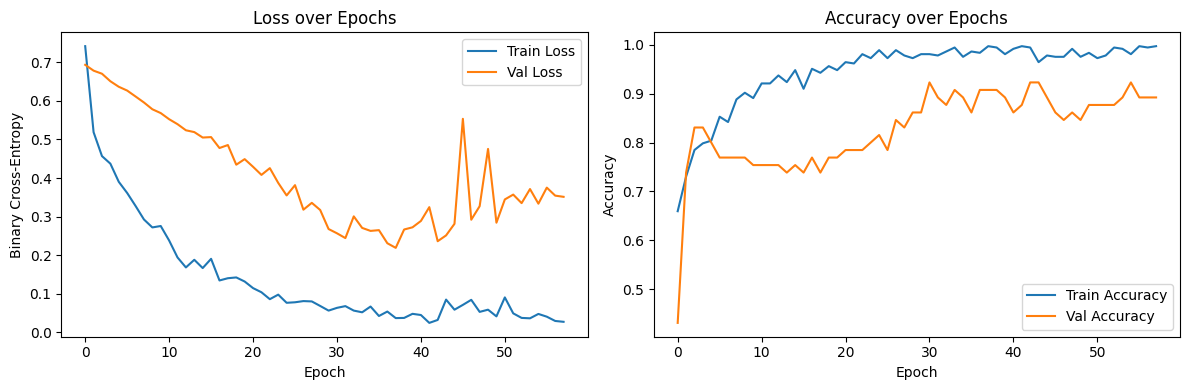

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# loss curve
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].legend()

# accuracy curve
axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Evaluate on the Test Set

In [10]:
# get predicted probabilities, then threshold at 0.5
y_prob = model.predict(X_test_cnn).ravel()
y_pred = (y_prob >= 0.4).astype(int)

# print the full classification report
print(classification_report(y_test, y_pred, target_names=['No PCOS', 'PCOS']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
              precision    recall  f1-score   support

     No PCOS       0.90      0.89      0.90        73
        PCOS       0.78      0.81      0.79        36

    accuracy                           0.86       109
   macro avg       0.84      0.85      0.85       109
weighted avg       0.86      0.86      0.86       109



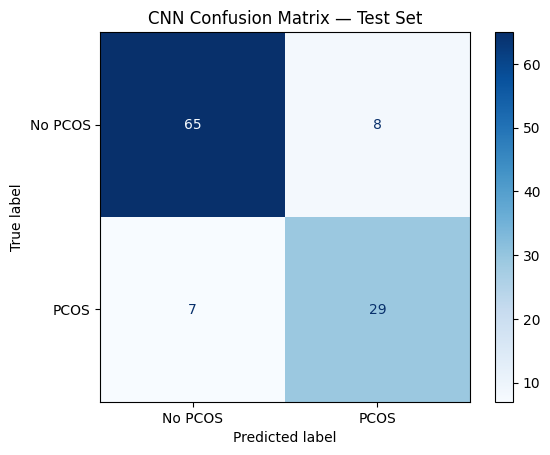

In [11]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No PCOS', 'PCOS'])
disp.plot(cmap='Blues')
plt.title('CNN Confusion Matrix — Test Set')
plt.show()

## 8. What the Filters Are Looking At

One thing we can do with a 1D CNN is look at the activation of each filter
across the feature sequence. This gives a rough sense of which parts of the
feature vector the network is responding to most strongly.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


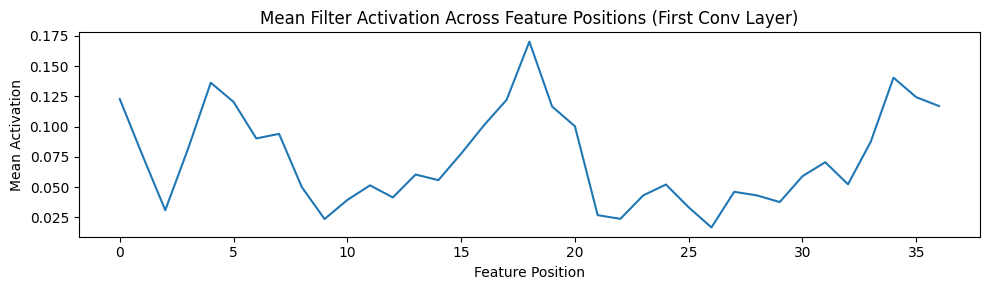


Feature names (in order):
   0: Follicle No. (L)
   1: Follicle No. (R)
   2: Avg. F size (L) (mm)
   3: Avg. F size (R) (mm)
   4: LH(mIU/mL)
   5: FSH(mIU/mL)
   6: FSH/LH
   7: AMH(ng/mL)
   8: Cycle(R/I)
   9: Cycle length(days)
  10: Waist:Hip Ratio
  11: Weight gain(Y/N)
  12: hair growth(Y/N)
  13: Skin darkening (Y/N)
  14: Pimples(Y/N)
  15:  Age (yrs)
  16: Weight (Kg)
  17: Height(Cm) 
  18: BMI
  19: Blood Group
  20: Pulse rate(bpm) 
  21: RR (breaths/min)
  22: Hb(g/dl)
  23: Marraige Status (Yrs)
  24: Pregnant(Y/N)
  25: No. of abortions
  26:   I   beta-HCG(mIU/mL)
  27: II    beta-HCG(mIU/mL)
  28: Hip(inch)
  29: Waist(inch)
  30: TSH (mIU/L)
  31: PRL(ng/mL)
  32: Vit D3 (ng/mL)
  33: PRG(ng/mL)
  34: RBS(mg/dl)
  35: Hair loss(Y/N)
  36: Fast food (Y/N)
  37: Reg.Exercise(Y/N)
  38: BP _Systolic (mmHg)
  39: BP _Diastolic (mmHg)
  40: Endometrium (mm)


In [12]:
# build the activation sub-model using an explicit input layer
# (more compatible with newer Keras versions)
inp = keras.Input(shape=(n_features, 1))
out = model.layers[0](inp)    # pass through the first Conv1D layer only
activation_model = keras.Model(inputs=inp, outputs=out)

# get activations for the first test sample
sample = X_test_cnn[[0]]                               # shape (1, n_features, 1)
activations = activation_model.predict(sample)[0]      # shape (n_features-2, 32 filters)

# plot the mean activation across all 32 filters at each position
mean_activation = activations.mean(axis=1)

plt.figure(figsize=(10, 3))
plt.plot(mean_activation)
plt.title('Mean Filter Activation Across Feature Positions (First Conv Layer)')
plt.xlabel('Feature Position')
plt.ylabel('Mean Activation')
plt.tight_layout()
plt.show()

# the feature names (minus dropped columns) for reference
feature_names = X.columns.tolist()
print('\nFeature names (in order):')
for i, name in enumerate(feature_names):
    print(f'  {i:>2}: {name}')

In [13]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.4f}')

AUC-ROC: 0.9326


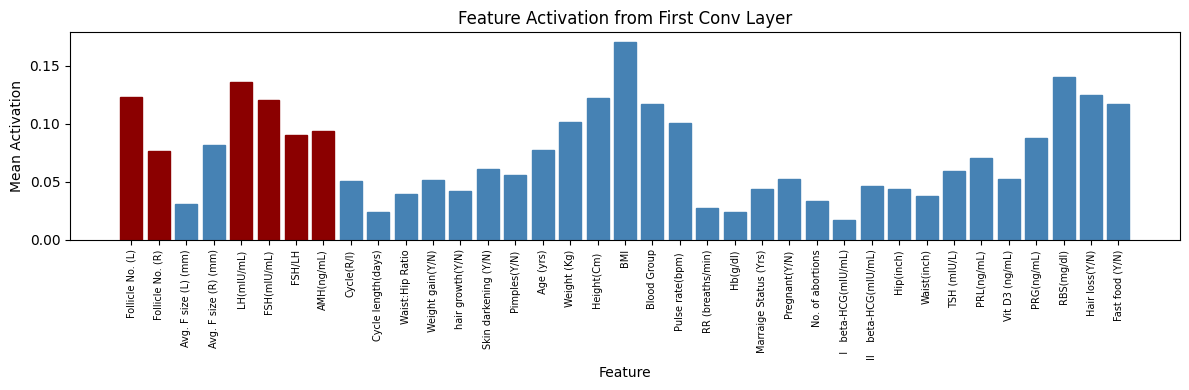

In [14]:
# bar chart version of feature importance from activation plot
plt.figure(figsize=(12, 4))
bars = plt.bar(range(len(mean_activation)), mean_activation)

# highlight the top clinical features in a different color
top_positions = [0, 1, 4, 5, 6, 7]  # follicles, LH, FSH, FSH/LH, AMH
for i, bar in enumerate(bars):
    if i in top_positions:
        bar.set_color('darkred')
    else:
        bar.set_color('steelblue')

plt.xticks(
    range(len(mean_activation)),
    [X.columns[i] if i < len(X.columns) else '' for i in range(len(mean_activation))],
    rotation=90, fontsize=7
)
plt.title('Feature Activation from First Conv Layer')
plt.xlabel('Feature')
plt.ylabel('Mean Activation')
plt.tight_layout()
plt.show()